# **Logistic Regression**

### **Q1. Data Loading & Understanding**

In [11]:
# Load the dataset

from google.colab import files
uploaded = files.upload()

Saving loan_approval - loan_approval.csv to loan_approval - loan_approval.csv


In [12]:
# Display the first 5 rows

import pandas as pd

df = pd.read_csv("loan_approval - loan_approval.csv")
print(df.head())

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  


In [14]:
# Check the shape of the dataset

df.shape

(2000, 8)

In [15]:
# Display the data types of each column

df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


### Overall Conclusion



*   Dataset contains 2000 loan applications and 8 variables.
*   There are 5 numerical features, 2 categorical features, and 1 binary target variable.


*   The target variable (loan_approved) is appropriate for a Logistic Regression Classification Model.
*   Before model building, categorical columns (name, city) should be encoded or removed, and further EDA should be performed.





## **Q2. Data Cleaning**

In [16]:
# Check missing values in each column

df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


## Interpretation

*   If all columns show 0 missing values, the dataset is complete and no handling is required.
*   If any column contains missing values, they must be treated before building the model.



In [21]:
# Handle Missing Values Appropriately For Numerical Columns

numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
categorical_cols = df.select_dtypes(include=['object','bool']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
# Verify Missing Values Have Been Handled

df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [23]:
# Identify Categorical Columns Present in the Dataset

categorical_cols = df.select_dtypes(include=['object','bool']).columns

print(categorical_cols)

Index(['name', 'city', 'loan_approved'], dtype='object')


In [24]:
list(categorical_cols)

['name', 'city', 'loan_approved']

## Interpretation



*   name is usually not useful for prediction and can be dropped before modeling.
*   city is a categorical feature and should be encoded (e.g., Label Encoding or One-Hot Encoding).

*   loan_approved is the target variable and should be converted to 0 and 1 if required.






## Conclusion



*   Missing values were checked using isnull().sum().
*   Numerical missing values should be filled using the median.


*   Categorical missing values should be filled using the mode.
*   The categorical columns identified are name, city, and loan_approved.


*   Further preprocessing (encoding and feature selection) will be required before applying Logistic Regression.







### **Q3. Exploratory Data Analysis (EDA)**

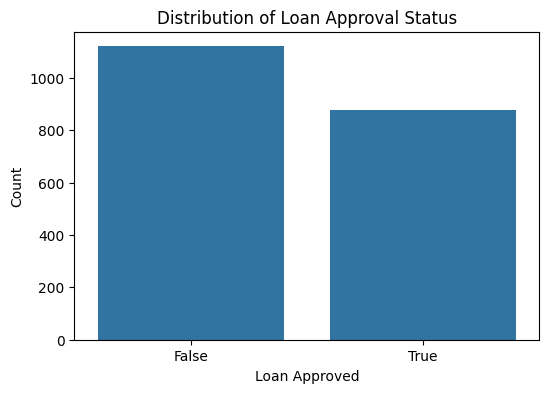

In [26]:
# Plot the Distribution of the Target Variable

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='loan_approved', data=df)

plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

## Interpretation



*   This chart shows the number of approved and rejected loan applications.
*   If both classes have similar counts, the dataset is balanced.

*   If one class dominates, the dataset is imbalanced and special handling may be required during model building.






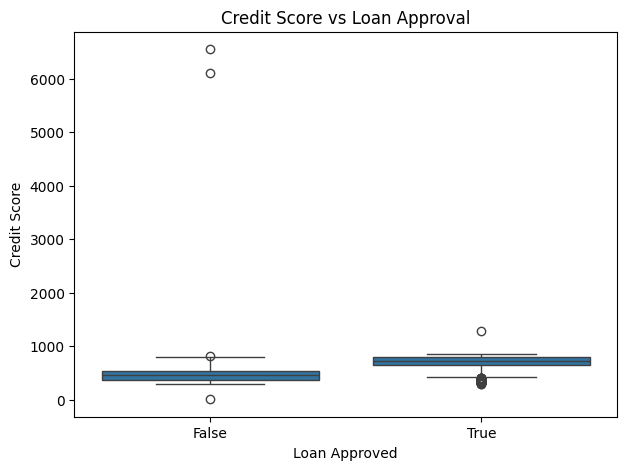

In [27]:
# Analyze the Relationship Between a Numerical Feature and the Target Variable

plt.figure(figsize=(7,5))
sns.boxplot(x='loan_approved', y='credit_score', data=df)

plt.title('Credit Score vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Credit Score')
plt.show()

## Interpretation



*   Compare the median credit scores of approved and rejected applicants.
*   If approved applicants have higher credit scores, it suggests that credit score positively influences loan approval.


*   A wider spread indicates greater variability in applicants' credit scores.





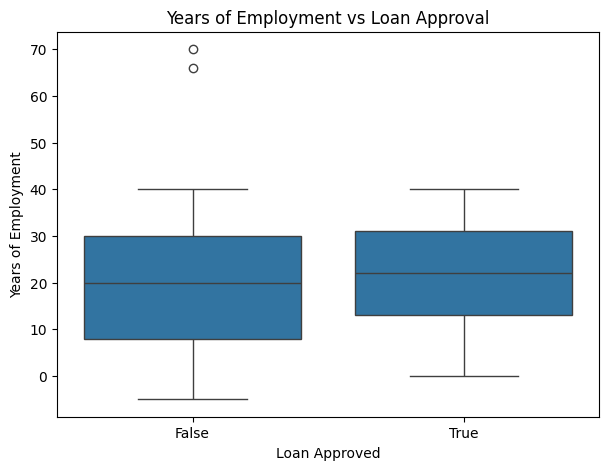

In [28]:
# Analyze the Relationship Between Years of Employment and the Target Variable

plt.figure(figsize=(7,5))
sns.boxplot(x='loan_approved', y='years_employed', data=df)

plt.title('Years of Employment vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Years of Employment')
plt.show()

## Interpretation



*   Applicants with more years of employment are generally considered financially stable.
*   If the median or average years employed is higher for approved loans, it indicates that employment history positively affects approval chances.


*   If both groups show similar values, years of employment may not be a strong predictor.






## **Q4. Outlier Detection and Treatment**

In [29]:
# Detect Outliers Using the IQR Method

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points'], dtype='object')


In [30]:
# Detect Outliers

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
credit_score: 3 outliers
loan_amount: 0 outliers
years_employed: 2 outliers
points: 0 outliers


## Interpretation



*   Q1 = 25th percentile
*   Q3 = 75th percentile

*   IQR = Q3 − Q1
*   Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.

The output will show the number of outliers present in each numerical feature.





In [31]:
# Treat Outliers Using Capping (Winsorization)

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound,
                           upper=upper_bound)

In [32]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
credit_score: 0 outliers
loan_amount: 0 outliers
years_employed: 0 outliers
points: 0 outliers


## Interpretation

Outlier Detection



*   The IQR method was used to identify extreme values in numerical variables.
*   Outliers were detected by calculating the lower and upper bounds using the IQR formula.

Outlier Treatment



*   Instead of deleting observations, outliers were treated using capping.
*   Values below the lower limit were replaced with the lower bound.


*   Values above the upper limit were replaced with the upper bound.

Conclusion



*   Outliers were successfully identified and handled.
*   Capping preserved all records while reducing the influence of extreme values.

*   The cleaned dataset is now more suitable for building a Logistic Regression model.











### **Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.**

In [33]:
# Step 1: Check Current Target Variable Values

df['loan_approved'].unique()

array([False,  True])

In [34]:
# Step 2: Convert Target Variable to Numerical Format

df['loan_approved'] = df['loan_approved'].astype(int)

In [35]:
print(df['loan_approved'].head())
print(df['loan_approved'].dtype)

0    0
1    0
2    0
3    0
4    0
Name: loan_approved, dtype: int64
int64


In [36]:
# Step 3: Drop Unnecessary Columns

df.drop('name', axis=1, inplace=True)

In [37]:
# Check Remaining Columns

df.columns

Index(['city', 'income', 'credit_score', 'loan_amount', 'years_employed',
       'points', 'loan_approved'],
      dtype='object')

## Interpretation

Target Variable Conversion



*   The target variable loan_approved was converted from a categorical/boolean format into numerical values.
*   Logistic Regression requires the target variable to be numeric.


*   Here, 1 = Loan Approved
*   0 = Loan Not Approved

Dropping Unnecessary Columns



*   The name column was removed because it is a unique identifier and has no predictive value.
*   Keeping such columns may introduce noise into the model.

Conclusion



*   The target variable is now in a machine-learning-friendly format.
*   Irrelevant columns have been removed.

*   The dataset is ready for encoding categorical features (such as city) and building the Logistic Regression model.










### **Q6. Feature Selection and Data Splitting**

In [38]:
# Separate Independent Variables (X) and Dependent Variable (y)

df.columns

Index(['city', 'income', 'credit_score', 'loan_amount', 'years_employed',
       'points', 'loan_approved'],
      dtype='object')

In [39]:
# Create X and y

# Independent variables (Features)
X = df.drop('loan_approved', axis=1)

# Dependent variable (Target)
y = df['loan_approved']

In [40]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2000, 6)
y Shape: (2000,)


## Interpretation



*   X contains all predictor variables.
*   y contains the target variable (loan_approved).


*   There are 2000 observations available for model training.






In [41]:
# Split the Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1600, 6)
X_test Shape : (400, 6)
y_train Shape: (1600,)
y_test Shape : (400,)


### **Conclusion**



*   Features and target variable were successfully separated.
*   The categorical variable (city) was encoded using One-Hot Encoding.


*   The dataset was split into training and testing sets using an 80:20 ratio.
*   The data is now ready for Logistic Regression model training.





### **Q7. Apply feature scaling to the dataset using StandardScaler.**

In [43]:
from sklearn.preprocessing import StandardScaler

In [46]:
# Apply One-Hot Encoding Before Scaling

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# Convert city into dummy variables
X = pd.get_dummies(X, columns=['city'], drop_first=True)

In [47]:
# Now split the data:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [48]:
# Then scale:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
print(X_train_scaled[:5])

[[-1.1701829  -0.67555613 -0.21763755 ...  0.         -0.02500782
  -0.02500782]
 [-0.58084238 -0.40663018 -0.20015315 ...  0.         -0.02500782
  -0.02500782]
 [-0.05506472  1.36583635 -0.53624989 ...  0.         -0.02500782
  -0.02500782]
 [-0.57411799 -1.26841563 -0.85854316 ...  0.         -0.02500782
  -0.02500782]
 [ 0.18017296  1.15191797 -1.20334669 ...  0.         -0.02500782
  -0.02500782]]


### **Q8. Logistic Regression Model Building**

In [50]:
# Train a Logistic Regression Model

from sklearn.linear_model import LogisticRegression

In [51]:
# Create model
log_model = LogisticRegression(random_state=42)

# Train model
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [52]:
print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [53]:
# Predict the Output for Test Data

y_pred = log_model.predict(X_test_scaled)

In [54]:
# Display First 10 Predictions

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[0 1 1 1 1 0 1 1 0 1]


In [55]:
# Compare Actual vs Predicted Values

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1
5,1,0
6,0,1
7,1,1
8,0,0
9,1,1


### Interpretation:



*   First column = Probability of class 0 (Not Approved)
*   Second column = Probability of class 1 (Approved)



### Conclusion



*   The Logistic Regression model was successfully trained.
*   Predictions for the test dataset were generated.
*   The model is now ready for evaluation using Accuracy, Confusion Matrix, Precision, Recall, and F1-Score in the next step.





## **Q9. Model Evaluation – Confusion Matrix**


In [56]:
# Generate the Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[207  10]
 [ 24 159]]


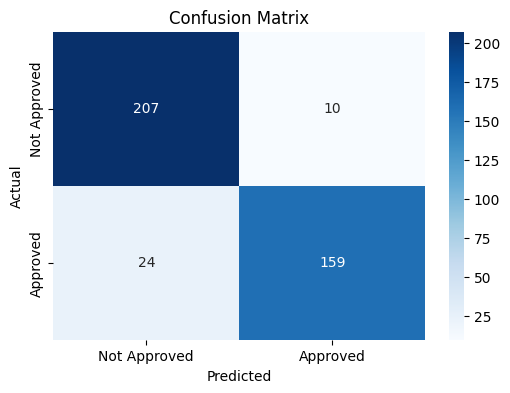

In [58]:
# Visualize Using Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Approved', 'Approved'],
    yticklabels=['Not Approved', 'Approved']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [59]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 207
False Positives: 10
False Negatives: 24
True Positives : 159


## Interpretation

The confusion matrix consists of four values:

True Negative (TN)



*   Model predicted Not Approved (0)
*   Actual value was Not Approved (0)
*   Correct rejection of loan applications

False Positive (FP)



*   Model predicted Approved (1)
*   Actual value was Not Approved (0)
*   Incorrect approval of a loan application


False Negative (FN)



*   Model predicted Not Approved (0)
*   Actual value was Approved (1)
*   Incorrect rejection of a loan application

True Positive (TP)



*   Model predicted Approved (1)
*   Actual value was Approved (1)
*   Correct approval of a loan application













## **Q10. Model Evaluation – ROC Curve & AUC**

In [60]:
# Plot the ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [61]:
# Get Prediction Probabilities

# Probability of class 1 (Loan Approved)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [62]:
# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

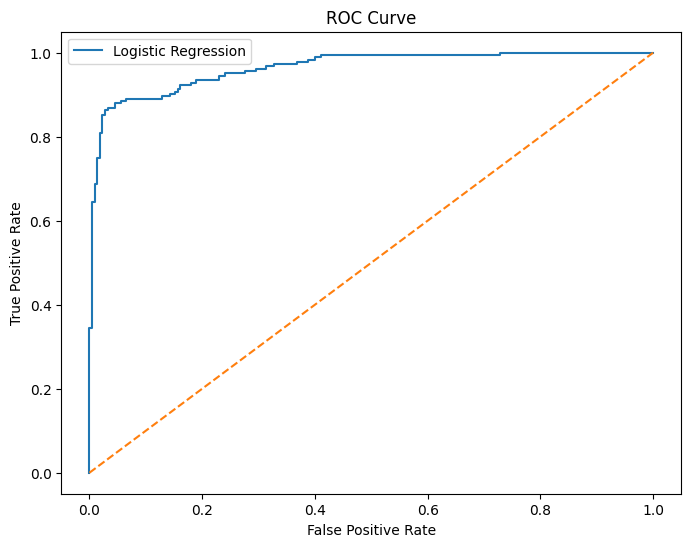

In [63]:
# Plot ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Interpretation



*   The diagonal line represents a random classifier.
*   The closer the ROC curve is to the top-left corner, the better the model.
*   A curve above the diagonal indicates the model performs better than random guessing.






In [64]:
# Calculate the AUC Score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.963687643222281


## Interpretation



*   The model has excellent classification performance.
*   There is a 96% chance that the model will correctly rank a randomly selected approved loan higher than a randomly selected non-approved loan.

